# Emission Spectroscopy with Equilibirum Chemistry

Last update: March 23th (2026) Hajime Kawahara for v2.1

In this getting started guide, we will use ExoJAX to simulate a high-resolution emission spectrum from an atmosphere with CO molecular absorption and hydrogen molecule CIA continuum absorption as the opacity sources. We assume the thermochemical equilibrium. We will then add appropriate noise to the simulated spectrum to create a mock spectrum and perform spectral retrieval using NumPyro's HMC NUTS. 


First, we recommend 64-bit if you do not think about numerical errors. Use jax.config to set 64-bit. 
(But note that 32-bit is sufficient in most cases. Consider to use 32-bit (faster, less device memory) for your real use case.) 

In [1]:
from jax import config
config.update("jax_enable_x64", True)

## 1. Loading a molecular database using mdb

ExoJAX has an API for molecular databases, called `mdb` (or `adb` for atomic datbases). Prior to loading the database, define the wavenumber range first.

In [2]:
from exojax.utils.grids import wavenumber_grid

nu_grid, wav, resolution = wavenumber_grid(
    22920.0, 23000.0, 3500, unit="AA", xsmode="premodit"
)
print("Resolution=", resolution)

xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Resolution= 1004211.9840291934


/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(


Then, let's load the molecular database. We here use Carbon monoxide in Exomol. `CO/12C-16O/Li2015` means `Carbon monoxide/ isotopes = 12C + 16O / database name`. You can check the database name in the ExoMol website (https://www.exomol.com/).  

In [3]:
from exojax.database.exomol.api import MdbExomol
mdb = MdbExomol(".database/CO/12C-16O/Li2015", nurange=nu_grid)

/home/kawahara/exojax/src/exojax/utils/molname.py:197: FutureWarning: e2s will be replaced to exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(


HITRAN exact name= (12C)(16O)
radis engine =  vaex
Molecule:  CO
Isotopologue:  12C-16O
ExoMol database:  None
Local folder:  .database/CO/12C-16O/Li2015
Transition files: 
	 => File 12C-16O__Li2015.trans
Broadener:  H2
Broadening code level: a0


/home/kawahara/anaconda3/lib/python3.10/site-packages/radis/api/exomolapi.py:727: AccuracyWarning: The default broadening parameter (alpha = 0.07 cm^-1 and n = 0.5) are used for J'' > 80 up to J'' = 152
  warnings.warn(


## 2. Computation of the Cross Section using opa

ExoJAX has various opacity calculator classes, so-called `opa`. Here, we use a memory-saved opa, `OpaPremodit`. We assume the robust tempreature range we will use is 500-1500K.

In [4]:
from exojax.opacity import OpaPremodit
opa = OpaPremodit(mdb, nu_grid, auto_trange=[500.0, 1500.0], dit_grid_resolution=1.0)

/home/kawahara/exojax/src/exojax/opacity/premodit/core.py:28: UserWarning: dit_grid_resolution is not None. Ignoring broadening_parameter_resolution.
  warnings.warn(


default elower grid trange (degt) file version: 2
Robust range: 485.7803992045456 - 1514.171191195336 K
max value of  ngamma_ref_grid : 9.450919102366303
min value of  ngamma_ref_grid : 7.881095721823979
ngamma_ref_grid grid : [7.88109541 9.4509201 ]
max value of  n_Texp_grid : 0.658
min value of  n_Texp_grid : 0.5
n_Texp_grid grid : [0.49999997 0.65800005]


uniqidx: 0it [00:00, ?it/s]

Premodit: Twt= 1108.7151960064205 K Tref= 570.4914318566549 K
Making LSD:|####################| 100%


Then let's compute cross section for two different temperature 500 and 1500 K for P=1.0 bar. opa.xsvector can do that!

In [5]:
P = 1.0  # bar
T_1 = 500.0  # K
xsv_1 = opa.xsvector(T_1, P)  # cm2

T_2 = 1500.0  # K
xsv_2 = opa.xsvector(T_2, P)  # cm2

Plot them. It can be seen that different lines are stronger at different temperatures.

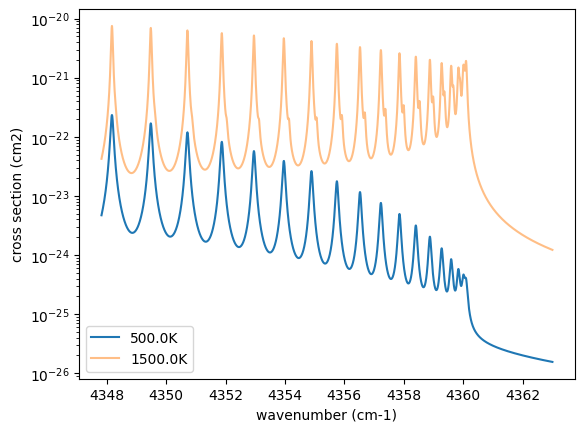

In [6]:
import matplotlib.pyplot as plt

plt.plot(nu_grid, xsv_1, label=str(T_1) + "K")  # cm2
plt.plot(nu_grid, xsv_2, alpha=0.5, label=str(T_2) + "K")  # cm2
plt.yscale("log")
plt.legend()
plt.xlabel("wavenumber (cm-1)")
plt.ylabel("cross section (cm2)")
plt.show()

## 3. Atmospheric Radiative Transfer

ExoJAX can solve the radiative transfer and derive the emission spectrum. To do so, ExoJAX has `art` class. `ArtEmisPure` means Atomospheric Radiative Transfer for Emission with Pure absorption. So, `ArtEmisPure` does not include scattering.
We set the number of the atmospheric layer to 200 (nlayer) and the pressure at bottom and top atmosphere to 100 and 1.e-5 bar.

Since v1.5, one can choose the rtsolver (radiative transfer solver) from the flux-based 2 stream solver (`fbase2st`) and the intensity-based n-stream sovler (`ibased`). Use `rtsolver` option. In the latter case, the number of the stream (`nstream`) can be specified. Note that the default rtsolver for the pure absorption (i.e. no scattering nor reflection) has been `ibased` since v1.5.
In our experience, `ibased` is faster and more accurate than `fbased`.

In [7]:
from exojax.rt import ArtEmisPure

art = ArtEmisPure(
    nu_grid=nu_grid,
    pressure_btm=1.0e1,
    pressure_top=1.0e-5,
    nlayer=100,
    rtsolver="ibased",
    nstream=8,
)

rtsolver:  ibased
Intensity-based n-stream solver, isothermal layer (e.g. NEMESIS, pRT like)


Let's assume the power law temperature model, within 500 - 1500 K.

$T = T_0 P^\alpha$

where $T_0=1200$ K and $\alpha=0.1$.

In [8]:
art.change_temperature_range(500.0, 1500.0)
Tarr = art.powerlaw_temperature(1200.0, 0.1)

Sets chemistry presets

In [9]:
from exogibbs.presets.fastchem import chemsetup
# chemical setup
chem = chemsetup()
idx_co = chem.species.index("C1O1")
print("idx for CO=",idx_co, "JANAF name", chem.species[idx_co])  # check index of CO
idx_h2 = chem.species.index("H2")
print("idx for H2=",idx_h2, "JANAF name", chem.species[idx_h2])  # check index of H2
print("element:", chem.elements)

restricting species to those composed of the default elements only.
fastchem presets in ExoGibbs
number of species: 523 elements: 28 molecules: 495
idx for CO= 102 JANAF name C1O1
idx for H2= 331 JANAF name H2
element: ('Al', 'Ar', 'C', 'Ca', 'Cl', 'Co', 'Cr', 'Cu', 'F', 'Fe', 'Ge', 'H', 'He', 'K', 'Mg', 'Mn', 'N', 'Na', 'Ne', 'Ni', 'O', 'P', 'S', 'Si', 'Ti', 'V', 'Zn', 'e-')


Sets solar abundance (AAG21) as the elemental vector. Do not forget e-! 

In [10]:
from exojax.utils.zsol import nsol
import jax.numpy as jnp
solar_abundance = nsol()
nsol_vector = jnp.array([solar_abundance[el] for el in chem.elements[:-1]]) # no solar abundance for e-
element_vector = jnp.append(nsol_vector, 0) 
    
print("element_vector:", element_vector)

Database for solar abundance =  AAG21
Asplund, M., Amarsi, A. M., & Grevesse, N. 2021, arXiv:2105.01661
element_vector: [2.48498877e-06 2.21474857e-06 2.66271344e-04 1.84214763e-06
 1.88505676e-07 8.04126604e-08 3.84879191e-07 1.39741188e-08
 2.31912646e-08 2.66271344e-05 3.84879191e-09 9.23260873e-01
 7.57398483e-02 1.08473694e-07 3.27585319e-05 2.42842352e-07
 6.24200958e-05 1.53223166e-06 1.06004531e-04 1.46326987e-06
 4.52193620e-04 2.37314585e-07 1.21709487e-05 2.98761362e-05
 8.61637180e-08 7.33372179e-09 3.35215762e-08 0.00000000e+00]


The mass mixing ratio of CO (MMR) should be computed based on the thermochemical equilibirum.

HITRAN exact name= (12C)(16O)
HITRAN exact name= H2


/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(


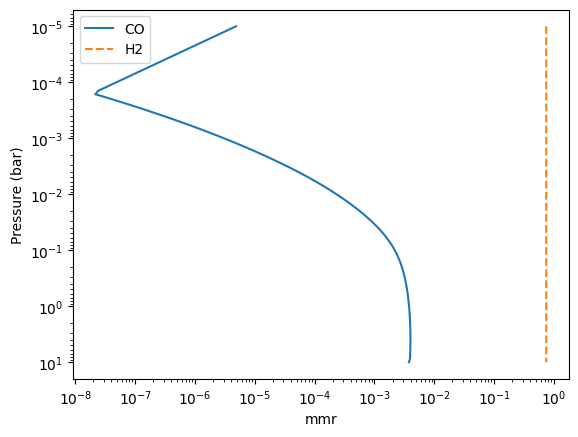

In [11]:
from exogibbs.api import get_default_equilibrium_grid_path
from exogibbs.api import load_equilibrium_grid_netcdf
from exogibbs.api.equilibrium import (
    EquilibriumOptions,
    GridEquilibriumInitializer,
    equilibrium_profile,
)

from exojax.atm.atmconvert import vmr_to_mmr
from exojax.database.molinfo.mass import isotope_molmass

# Thermodynamic conditions
Pref = 1.0  # bar, reference pressure

grid_path = get_default_equilibrium_grid_path("fastchem")
grid = load_equilibrium_grid_netcdf(str(grid_path))
initializer = GridEquilibriumInitializer(grid=grid, preset_name="fastchem")
method = "vmap_cold"
opts = EquilibriumOptions(epsilon_crit=1e-11, max_iter=1000, method=method)

res = equilibrium_profile(
    chem,
    Tarr,
    art.pressure,
    element_vector,
    Pref=Pref,
    initializer=initializer,
    options=opts,
)
nk_result = res.x
vmr_co = nk_result[:, idx_co]
vmr_h2 = nk_result[:, idx_h2]

mean_molecular_weight = 2.33  ## assume constant (not accurate)
molmass = isotope_molmass("12C-16O")
mmr_profile = vmr_to_mmr(vmr_co, molmass, mean_molecular_weight)
mmr_profile_h2 = vmr_to_mmr(vmr_h2, isotope_molmass("1H2"), mean_molecular_weight)

import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(mmr_profile, art.pressure, label="CO")
ax.plot(mmr_profile_h2, art.pressure, ls="--", label="H2")

ax.invert_yaxis()
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mmr")
ax.set_ylabel("Pressure (bar)")
plt.show()

Surface gravity is also important quantity of the atmospheric model, which is a function of planetary radius and mass. Here we assume 1 RJ and 10 MJ.

In [12]:
from exojax.utils.astrofunc import gravity_jupiter

gravity = gravity_jupiter(1.0, 10.0)

In addition to the CO cross section, we would consider [collisional induced absorption](https://en.wikipedia.org/wiki/Collision-induced_absorption_and_emission) (CIA) as a continuum opacity. `cdb` class can be used.

In [13]:
from exojax.database.contdb  import CdbCIA
from exojax.opacity import OpaCIA

cdb = CdbCIA(".database/H2-H2_2011.cia", nurange=nu_grid)
opacia = OpaCIA(cdb, nu_grid=nu_grid)

Load CIA:  H2-H2


Before running the radiative transfer, we need cross sections for layers, called `xsmatrix` for CO and `logacia_matrix` for CIA (strictly speaking, the latter is not cross section but coefficient because CIA intensity is proportional density square). See [here](CIA_opacity.html) for the details.

In [14]:
xsmatrix = opa.xsmatrix(Tarr, art.pressure)
logacia_matrix = opacia.logacia_matrix(Tarr)

Convert them to opacity

In [15]:
dtau_CO = art.opacity_profile_xs(xsmatrix, mmr_profile, mdb.molmass, gravity)
#vmrH2 = 0.855  # VMR of H2
dtaucia = art.opacity_profile_cia(logacia_matrix, Tarr, vmr_h2, vmr_h2, mean_molecular_weight, gravity)

Add two opacities.

In [16]:
dtau = dtau_CO + dtaucia

Then, run the radiative transfer.
As you can see, the emission spectrum has been generated. This spectrum shows a region near 4360 cm-1, or around 22940 AA, where CO features become increasingly dense. This region is referred to as the band head. If you're interested in why the band head occurs, please refer to [Quatum states of Carbon Monoxide and Fortrat Diagram](Fortrat.html).


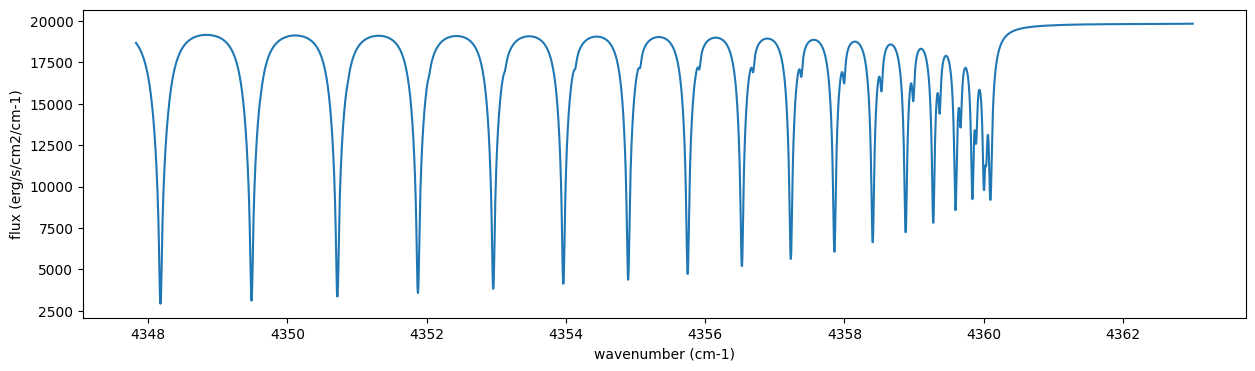

In [17]:
F = art.run(dtau, Tarr)

fig = plt.figure(figsize=(15, 4))
plt.plot(nu_grid, F)
plt.xlabel("wavenumber (cm-1)")
plt.ylabel("flux (erg/s/cm2/cm-1)")
plt.show()

You can check the contribution function too! 
You should check if the dominant contribution is within the layer. 
If not, you need to change `pressure_top` and `pressure_btm` in `ArtEmisPure`    

In [18]:
from exojax.plot.atmplot import plotcf

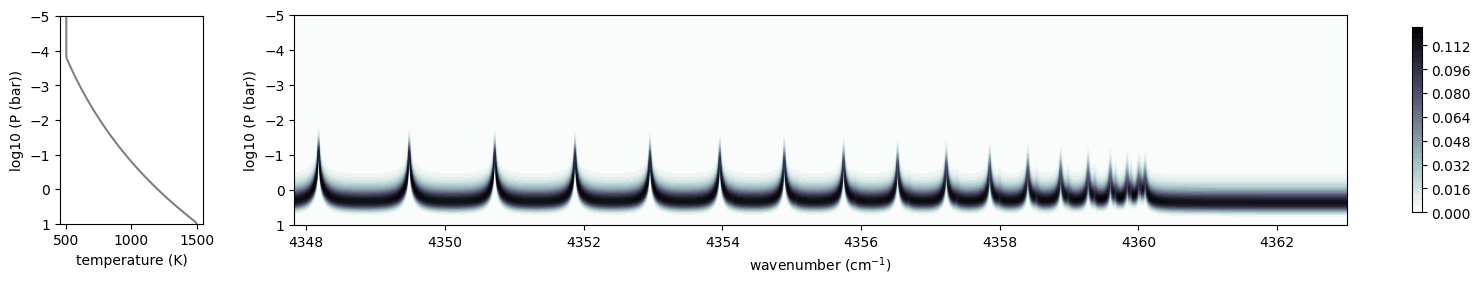

In [19]:
cf = plotcf(nu_grid, dtau, Tarr, art.pressure, art.dParr)

## 4. Spectral Operators: rotational broadening, instrumental profile, Doppler velocity shift and so on, any operation on spectra.

The above spectrum is called "raw spectrum" in ExoJAX. The effects applied to the raw spectrum is handled in ExoJAX by the spectral operator (`sop`).
First, we apply the spin rotational broadening of a planet.

In [20]:
from exojax.postproc.specop import SopRotation

sop_rot = SopRotation(nu_grid, vsini_max=100.0)

vsini = 10.0
u1 = 0.0
u2 = 0.0
Frot = sop_rot.rigid_rotation(F, vsini, u1, u2)

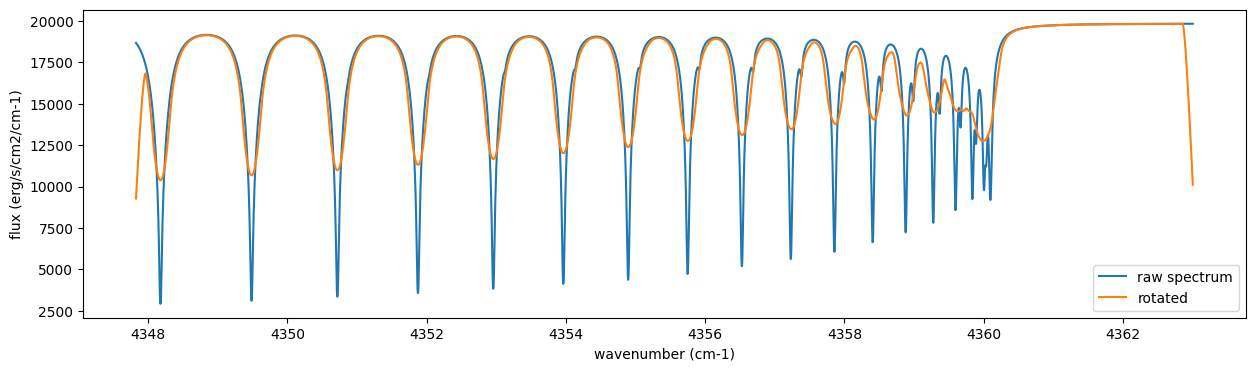

In [21]:
fig = plt.figure(figsize=(15, 4))
plt.plot(nu_grid, F, label="raw spectrum")
plt.plot(nu_grid, Frot, label="rotated")
plt.xlabel("wavenumber (cm-1)")
plt.ylabel("flux (erg/s/cm2/cm-1)")
plt.legend()
plt.show()

Then, the instrumental profile with relative radial velocity shift is applied. Also, we need to match the computed spectrum to the data grid. This process is called `sampling` (but just interpolation though). Below, let’s perform a simulation that includes noise for use in later analysis.

In [22]:
from exojax.postproc.specop import SopInstProfile
from exojax.utils.instfunc import resolution_to_gaussian_std

sop_inst = SopInstProfile(nu_grid, vrmax=1000.0)

RV = 40.0  # km/s
resolution_inst =70000.0
beta_inst = resolution_to_gaussian_std(resolution_inst)
Finst = sop_inst.ipgauss(Frot, beta_inst)
nu_obs = nu_grid[::5][:-50]


from numpy.random import normal
noise = 500.0
Fobs = sop_inst.sampling(Finst, RV, nu_obs) + normal(0.0, noise, len(nu_obs))

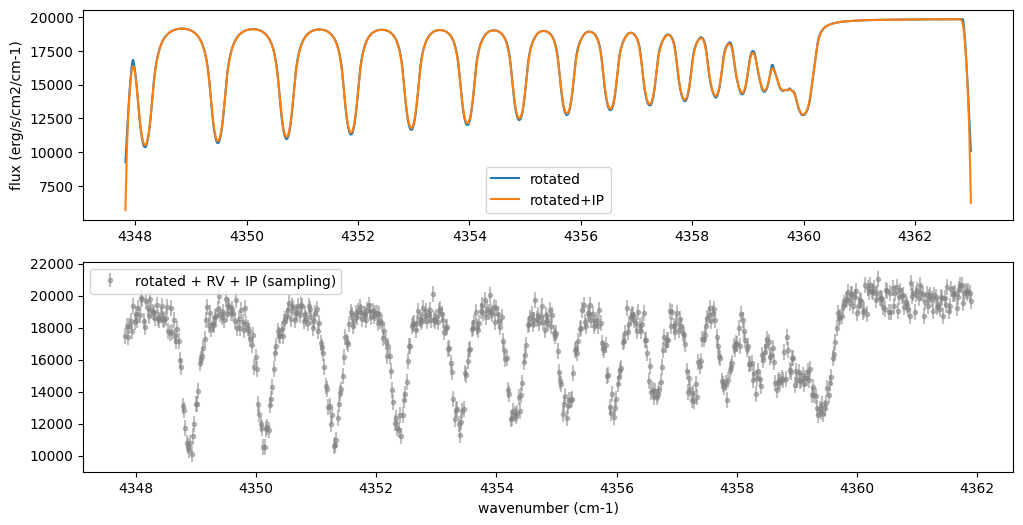

In [23]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(211)
plt.plot(nu_grid, Frot, label="rotated")
plt.plot(nu_grid, Finst, label="rotated+IP")
plt.ylabel("flux (erg/s/cm2/cm-1)")
plt.legend()
ax = fig.add_subplot(212)
plt.errorbar(nu_obs, Fobs, noise, fmt=".", label="rotated + RV + IP (sampling)", color="gray",alpha=0.5)
plt.xlabel("wavenumber (cm-1)")
plt.legend()
plt.show()

## 5. Retrieval of an Emission Spectrum

Next, let’s perform a “retrieval” on the simulated spectrum created above. Retrieval involves estimating the parameters of an atmospheric model in the form of a posterior distribution based on the spectrum. To do this, we first need a model. Here, we have compiled the forward modeling steps so far and defined the model as follows. The spectral model has six parameters.

In [26]:

def fspec(T0, alpha, g, RV, vsini, b_element_vector_in):
    #molecule
    Tarr = art.powerlaw_temperature(T0, alpha)
    xsmatrix = opa.xsmatrix(Tarr, art.pressure)
    
    # MMR profile from equilibrium chemistry
    res = equilibrium_profile(chem, Tarr, art.pressure, b_element_vector_in, Pref=Pref, options=opts)
    nk_result = res.x
    vmr_co = nk_result[:, idx_co]
    mmr_arr = vmr_to_mmr(vmr_co, molmass, mean_molecular_weight)
    vmr_h2 = nk_result[:, idx_h2]
    #opacity
    dtau = art.opacity_profile_xs(xsmatrix, mmr_arr, molmass, g)
    #continuum
    logacia_matrix = opacia.logacia_matrix(Tarr)
    dtaucH2H2 = art.opacity_profile_cia(logacia_matrix, Tarr, vmr_h2, vmr_h2,
                                        mean_molecular_weight, g)
    #total tau
    dtau = dtau + dtaucH2H2
    F = art.run(dtau, Tarr)
    Frot = sop_rot.rigid_rotation(F, vsini, u1, u2)
    Finst = sop_inst.ipgauss(Frot, beta_inst)
    mu = sop_inst.sampling(Finst, RV, nu_obs)
    return mu

Let’s verify that spectra are being generated from `fspec` with various parameter sets.

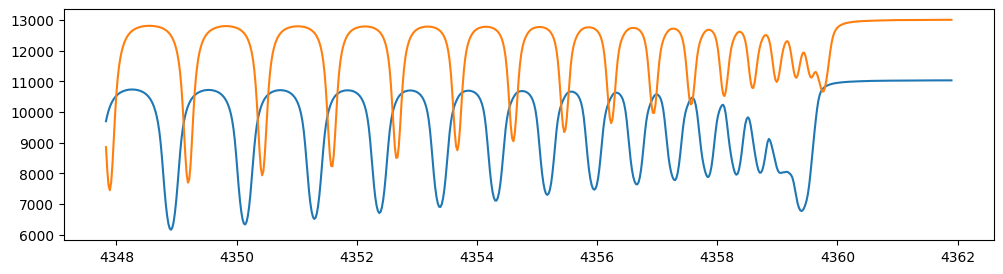

In [27]:
fig = plt.figure(figsize=(12, 3))

plt.plot(nu_obs, fspec(1200.0, 0.09,  gravity_jupiter(1.0, 1.0), 40.0, 10.0, element_vector),label="model")
plt.plot(nu_obs, fspec(1100.0, 0.12,  gravity_jupiter(1.0, 10.0), 20.0, 5.0, element_vector),label="model")

NumPyro is a probabilistic programming language (PPL), which requires the definition of a probabilistic model. In the probabilistic model `model_prob` defined below, the prior distributions of each parameter are specified. The previously defined spectral model is used within this probabilistic model as a function that provides the mean $\mu$. The spectrum is assumed to be generated according to a Gaussian distribution with this mean and a standard deviation $\sigma$. i.e. $f(\nu_i) \sim \mathcal{N}(\mu(\nu_i; {\bf p}), \sigma^2 I)$, where ${\bf p}$ is the spectral model parameter set, which are the arguments of `fspec`. 



In [28]:
from numpyro.infer import MCMC, NUTS
import numpyro.distributions as dist
import numpyro
from jax import random

In [29]:
from exogibbs.api.chemistry import element_indices_by_name, update_element_vector
# Compute indices once (outside jit/NumPyro tracing)
_idx_CO = element_indices_by_name(chem, ['C', 'O'])
_idx_C, _idx_O = map(int, list(_idx_CO))

In [30]:

def model_prob(spectrum):

    # atmospheric/spectral model parameters priors
    logg = numpyro.sample("logg", dist.Uniform(4.0, 5.0))
    RV = numpyro.sample("RV", dist.Uniform(35.0, 45.0))
    T0 = numpyro.sample("T0", dist.Uniform(1000.0, 1500.0))
    alpha = numpyro.sample("alpha", dist.Uniform(0.05, 0.2))
    vsini = numpyro.sample("vsini", dist.Uniform(5.0, 15.0))
    logZ = numpyro.sample("logZ", dist.Uniform(-1.0, 1.0))  #  logC [solar]
    scale = 10**logZ
    
    # Build element vector in a JAX-safe way (scale C/O; set e- to 0)
    element_vector_in = update_element_vector(
        element_vector,
        scale_indices=jnp.array([_idx_C,_idx_O]),
        scales=jnp.array([scale,scale]),
        )

    mu = fspec(T0, alpha, 10**logg, RV, vsini, element_vector_in)

    # noise model parameters priors
    sigmain = numpyro.sample("sigmain", dist.Exponential(1.0e-3))

    numpyro.sample("spectrum", dist.Normal(mu, sigmain), obs=spectrum)

Note that we did not account for the effects of limb darkening. However, in actual analyses, one possible approach might be to use an uninformative prior, such as the one proposed by Kipping.

```python
    from exojax.postproc.limb_darkening import ld_kipping
    q1 = numpyro.sample('q1', dist.Uniform(0.0,1.0))
    q2 = numpyro.sample('q2', dist.Uniform(0.0,1.0))
    u1,u2 = ld_kipping(q1,q2)
```

Now, let’s define NUTS and start sampling. 

In [31]:
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
num_warmup, num_samples = 500, 1000
#kernel = NUTS(model_prob, forward_mode_differentiation=True)
kernel = NUTS(model_prob, forward_mode_differentiation=False)

Since this process will take several hours, feel free to go for a long lunch break!

In [ ]:
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_key_, spectrum=Fobs)
mcmc.print_summary()

warmup:   7%|▋         | 99/1500 [06:24<14:16:48, 36.69s/it, 127 steps of size 1.81e-03. acc. prob=0.75]

After returning from your long lunch, if you're lucky and the sampling is complete, let’s write a predictive model for the spectrum.

In [57]:
from numpyro.diagnostics import hpdi
from numpyro.infer import Predictive
import jax.numpy as jnp

In [58]:
# SAMPLING
posterior_sample = mcmc.get_samples()
pred = Predictive(model_prob, posterior_sample, return_sites=['spectrum'])
predictions = pred(rng_key_, spectrum=None)
median_mu1 = jnp.median(predictions['spectrum'], axis=0)
hpdi_mu1 = hpdi(predictions['spectrum'], 0.9)

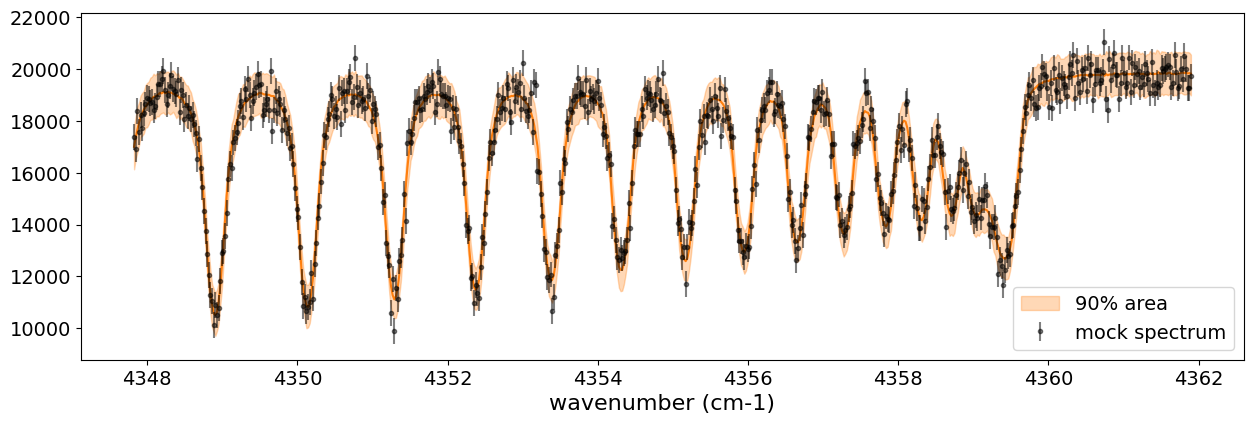

In [59]:

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 4.5))
ax.plot(nu_obs, median_mu1, color='C1')
ax.fill_between(nu_obs,
                hpdi_mu1[0],
                hpdi_mu1[1],
                alpha=0.3,
                interpolate=True,
                color='C1',
                label='90% area')
ax.errorbar(nu_obs, Fobs, noise, fmt=".", label="mock spectrum", color="black",alpha=0.5)
plt.xlabel('wavenumber (cm-1)', fontsize=16)
plt.legend(fontsize=14)
plt.tick_params(labelsize=14)
plt.show()

In [60]:
#save the result
import arviz
idata = arviz.from_numpyro(mcmc,
    posterior_predictive=predictions, coords = {"wavenumber": nu_obs,},dims = {"spectrum": ["wavenumber"],})
arviz.to_netcdf(idata, "posterior_logZ.nc")

'posterior_logZ.nc'

You can see that the predictions are working very well! Let’s also display a corner plot. Here, we’ve used ArviZ for visualization.

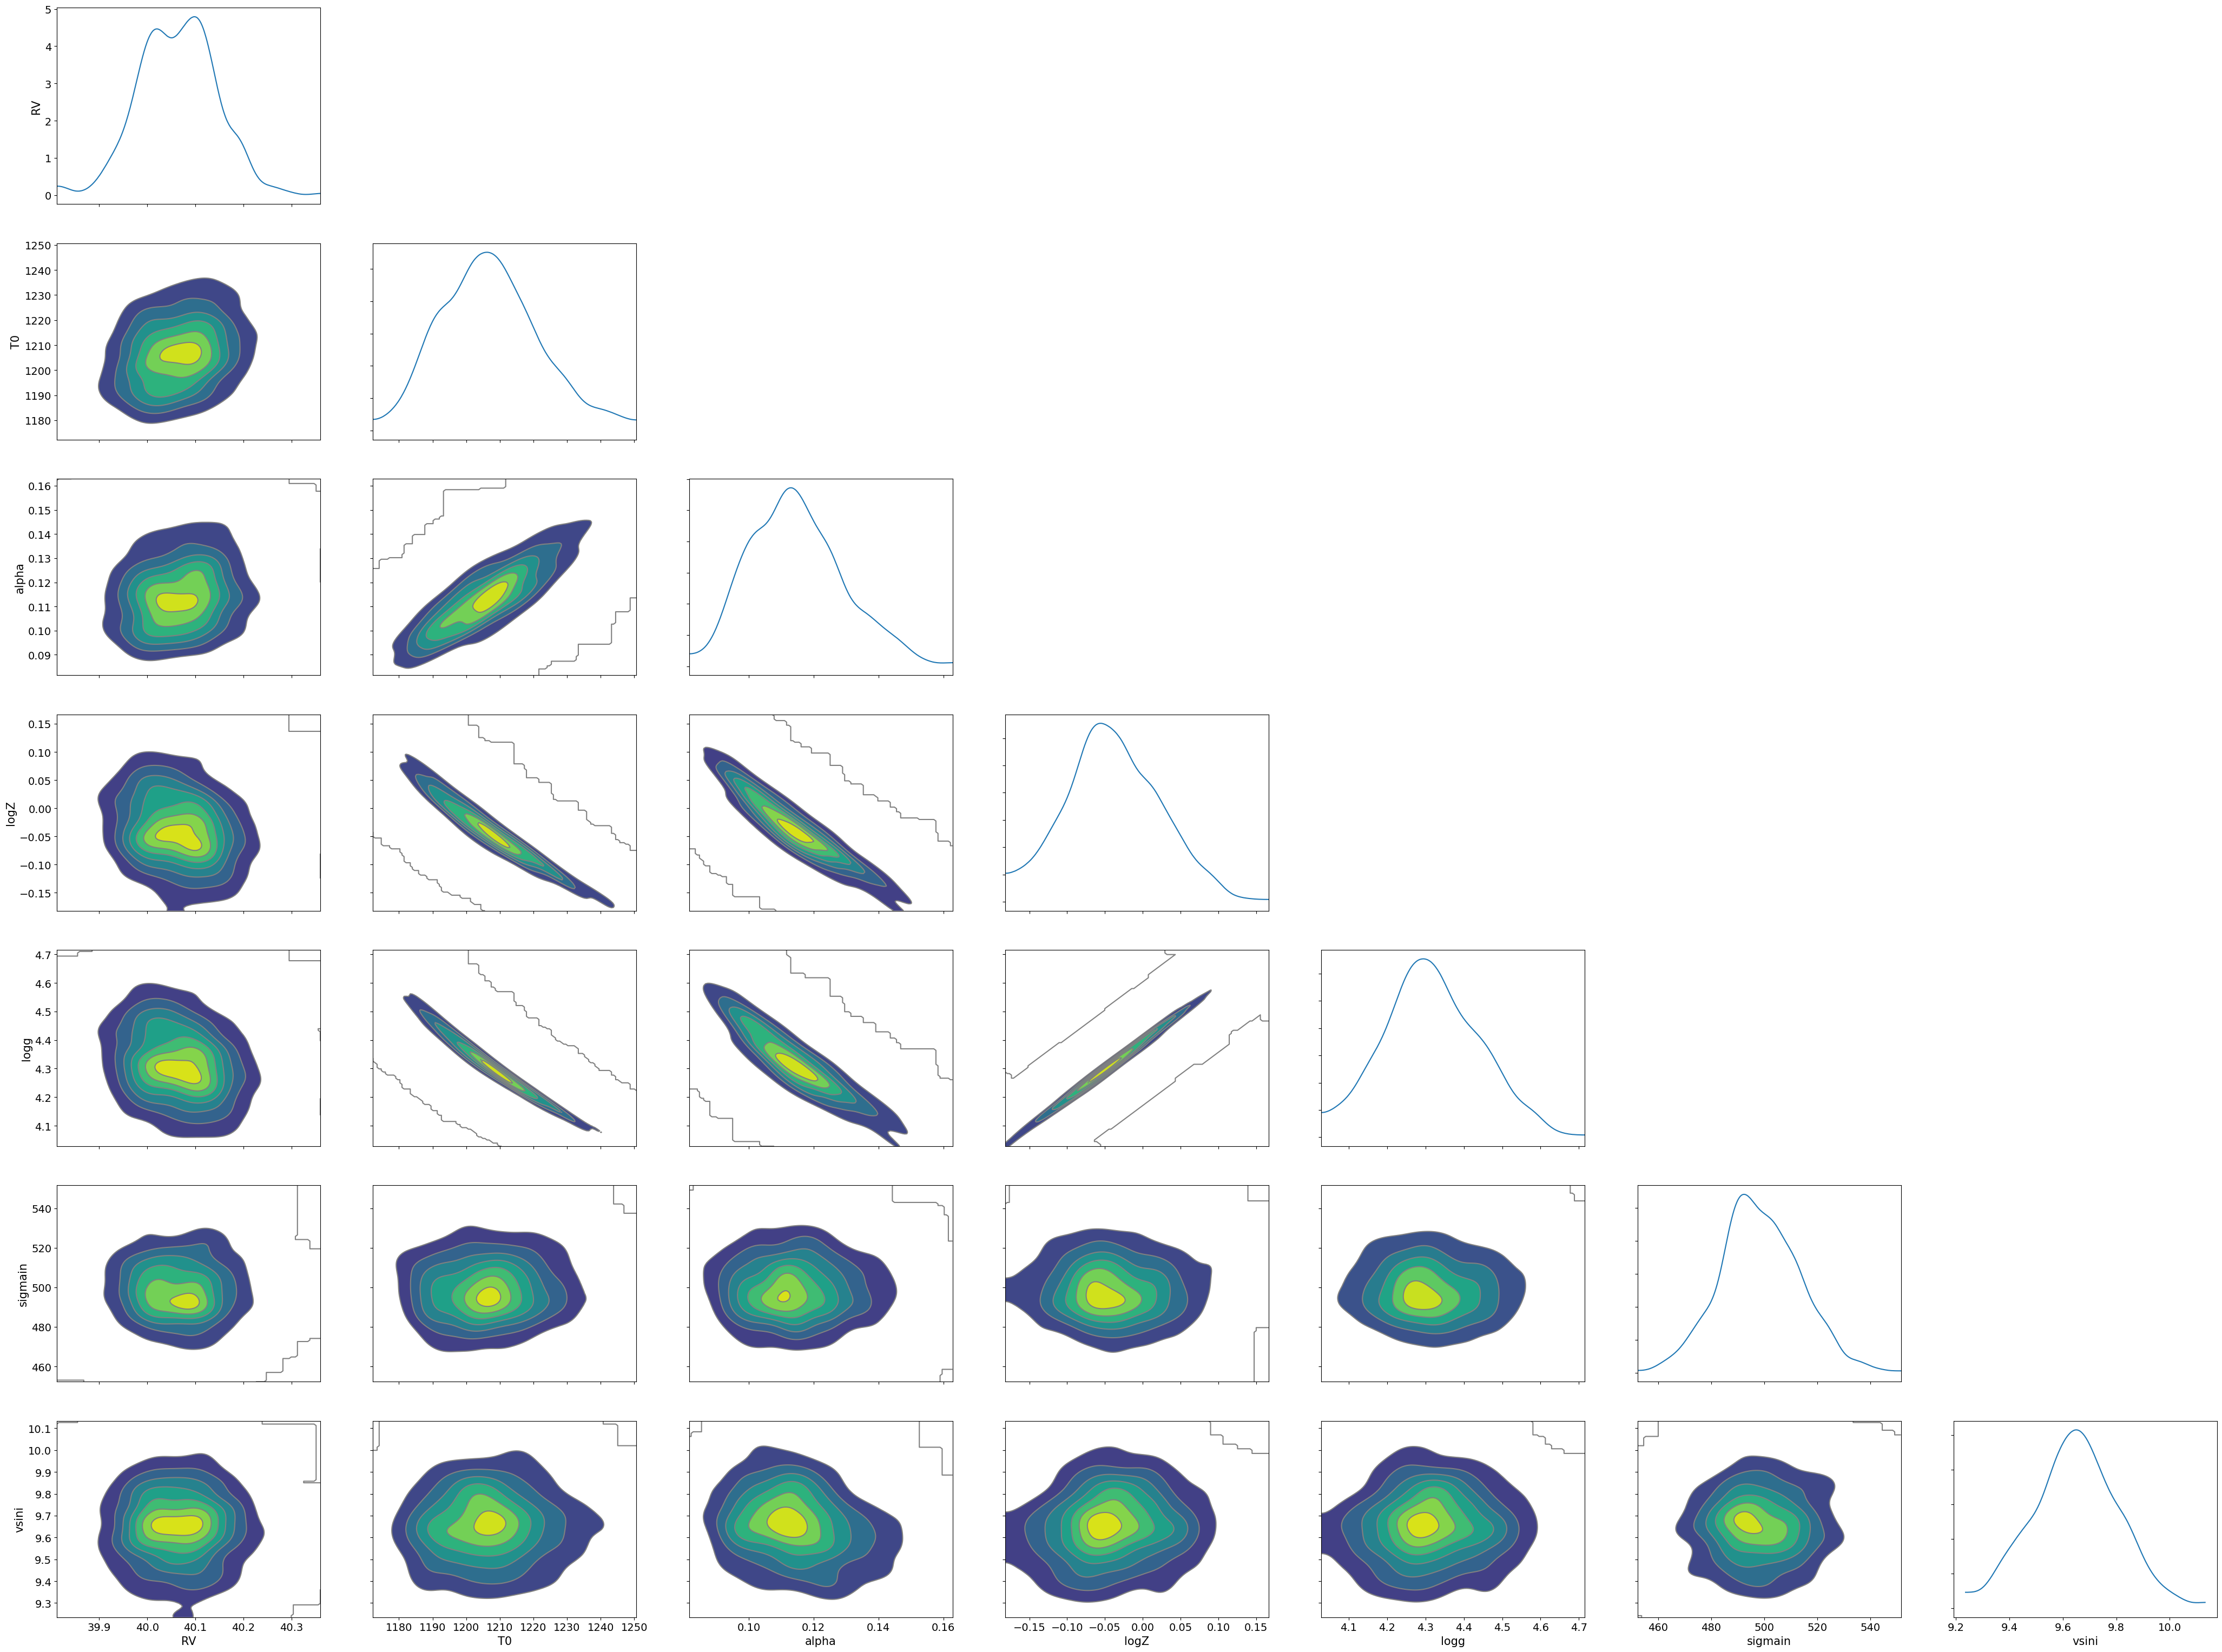

In [61]:
import arviz
pararr = ['T0', 'alpha', 'logg', 'logZ', 'vsini', 'RV']
arviz.plot_pair(arviz.from_numpyro(mcmc),
                kind='kde',
                divergences=False,
                marginals=True)
plt.show()

We see the strong degeneracy between metalicity and gravity!!!